<a href="https://colab.research.google.com/github/Vedant2100/s26/blob/main/wfl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
def bytes_per_element(dtype: str) -> int:
  d = dtype.lower()
  if d in ("fp32", "float32"):
      return 4
  if d in ("bf16", "bfloat16", "fp16", "float16"):
      return 2
  if d in ("fp8", "int8", "uint8"):
      return 1
  raise ValueError("Unknown dtype: {}".format(dtype))


def gb(num_bytes: float) -> float:
  # Decimal GB (1e9 bytes) keeps the arithmetic simple.
  return num_bytes / 1e9


def estimate_transformer_memory_gb(
  params_billions: float,
  batch_size: int = 1,
  seq_length: int = 2048,
  hidden_dim: int = 4096,
  num_layers: int = 32,
  *,
  param_dtype: str = "bf16",
  grad_dtype: str = "fp32",
  optimizer: str = "adam",
  fp32_master_weights: bool = True,
  kv_dtype=None,
  kv_head_ratio: float = 1.0,  # 1.0 = MHA, <1.0 = GQA/MQA
  activation_multiplier: float = 4.0,  # rough saved tensors per token per layer
  activation_checkpointing_factor: float = 1.0,  # ~0.25 is a common ballpark
  overhead_frac: float = 0.15,  # fragmentation + temp buffers + kernels
) -> dict:
  """Back-of-the-envelope VRAM estimate (decimal GB).

  Notes:
  - Optimizer states are assumed FP32 (common default).
  - Activations are intentionally a rough multiplier; the point is correct scaling.
  """

  params = params_billions * 1e9
  param_b = bytes_per_element(param_dtype)
  grad_b = bytes_per_element(grad_dtype)
  kv_b = bytes_per_element(kv_dtype or param_dtype)

  # Capacity terms
  weights_bytes = params * param_b

  # KV cache (inference): K and V per layer
  kv_cache_bytes = (
      2 * batch_size * seq_length * hidden_dim * kv_b * num_layers * kv_head_ratio
  )

  # Training-only terms
  grads_bytes = params * grad_b

  master_weights_bytes = 0
  if fp32_master_weights and param_b < 4:
      # Many mixed-precision setups keep an FP32 copy of weights.
      master_weights_bytes = params * 4

  optimizer_bytes = 0
  opt = optimizer.lower()
  if opt == "adam":
      # Adam keeps m and v (often FP32).
      optimizer_bytes = params * 2 * 4
  elif opt == "sgd":
      # SGD with momentum keeps 1 velocity buffer (FP32).
      optimizer_bytes = params * 1 * 4
  elif opt == "none":
      optimizer_bytes = 0
  else:
      raise ValueError("optimizer must be 'adam' or 'sgd'")

  # Activations (training): scales with tokens and depth.
  activations_bytes = (
      batch_size
      * seq_length
      * hidden_dim
      * num_layers
      * activation_multiplier
      * param_b
      * activation_checkpointing_factor
  )

  inference_total = weights_bytes + kv_cache_bytes
  training_total = (
      weights_bytes
      + grads_bytes
      + master_weights_bytes
      + optimizer_bytes
      + activations_bytes
  )

  # Add a simple overhead budget to each total.
  inference_total *= 1 + overhead_frac
  training_total *= 1 + overhead_frac

  return {
      "weights_gb": round(gb(weights_bytes), 2),
      "kv_cache_gb": round(gb(kv_cache_bytes), 2),
      "activations_gb": round(gb(activations_bytes), 2),
      "grads_gb": round(gb(grads_bytes), 2),
      "optimizer_states_gb": round(gb(optimizer_bytes), 2),
      "fp32_master_weights_gb": round(gb(master_weights_bytes), 2),
      "inference_total_gb": round(gb(inference_total), 2),
      "training_total_gb": round(gb(training_total), 2),
  }


def print_breakdown(title: str, b: dict):
  print(title)
  print("  Weights:          {:>7} GB".format(b['weights_gb']))
  print("  KV cache:         {:>7} GB".format(b['kv_cache_gb']))
  print("  Activations:      {:>7} GB".format(b['activations_gb']))
  print("  Grads:            {:>7} GB".format(b['grads_gb']))
  print("  Optimizer states: {:>7} GB".format(b['optimizer_states_gb']))
  if b["fp32_master_weights_gb"] > 0:
      print("  FP32 master:      {:>7} GB".format(b['fp32_master_weights_gb']))
  print("  -> Inference total (w/ overhead): {} GB".format(b['inference_total_gb']))
  print("  -> Training total  (w/ overhead): {} GB".format(b['training_total_gb']))
  print()


# Try a few scales with architecture params matching each model size.
# Key: hidden_dim and num_layers must scale with parameter count,
# otherwise KV cache and activation estimates will be wrong.
model_configs = [
  ("7B",   7,   4096, 32),   # Llama-7B-class
  ("70B",  70,  8192, 80),   # Llama-70B-class
  ("175B", 175, 12288, 96),  # GPT-3-175B-class
]

for name, params, hdim, nlayers in model_configs:
  b = estimate_transformer_memory_gb(
      params,
      batch_size=1,
      seq_length=2048,
      hidden_dim=hdim,
      num_layers=nlayers,
      param_dtype="bf16",
      optimizer="adam",
      overhead_frac=0.15,
  )
  print_breakdown("=== {} (h={}, L={}) @ seq=2048 (bf16 params) ===".format(name, hdim, nlayers), b)


# Now feel the KV-cache wall: increase seq_length and watch KV cache grow.
b = estimate_transformer_memory_gb(7, seq_length=128_000, kv_head_ratio=1.0, overhead_frac=0.15)
print_breakdown("=== 7B @ seq=128k (KV cache dominates) ===", b)

=== 7B (h=4096, L=32) @ seq=2048 (bf16 params) ===
  Weights:             14.0 GB
  KV cache:            1.07 GB
  Activations:         2.15 GB
  Grads:               28.0 GB
  Optimizer states:    56.0 GB
  FP32 master:         28.0 GB
  -> Inference total (w/ overhead): 17.33 GB
  -> Training total  (w/ overhead): 147.37 GB

=== 70B (h=8192, L=80) @ seq=2048 (bf16 params) ===
  Weights:            140.0 GB
  KV cache:            5.37 GB
  Activations:        10.74 GB
  Grads:              280.0 GB
  Optimizer states:   560.0 GB
  FP32 master:        280.0 GB
  -> Inference total (w/ overhead): 167.17 GB
  -> Training total  (w/ overhead): 1461.35 GB

=== 175B (h=12288, L=96) @ seq=2048 (bf16 params) ===
  Weights:            350.0 GB
  KV cache:            9.66 GB
  Activations:        19.33 GB
  Grads:              700.0 GB
  Optimizer states:  1400.0 GB
  FP32 master:        700.0 GB
  -> Inference total (w/ overhead): 413.61 GB
  -> Training total  (w/ overhead): 3644.73 GB

=== 7

In [ ]:
def gb(num_bytes: float) -> float:
  return num_bytes / 1e9


# Same shapes as the PyTorch example above
batch, seq, hidden = 32, 4096, 16384
dtype_bytes = 4  # float32

x = batch * seq * hidden * dtype_bytes          # input
y = batch * seq * hidden * dtype_bytes          # output
w = hidden * hidden * dtype_bytes               # weights

print("Input x:   {:.2f} GB".format(gb(x)))
print("Output y:  {:.2f} GB".format(gb(y)))
print("Weights W: {:.2f} GB".format(gb(w)))

# A common mistake is to count only forward tensors.
forward_only = gb(x + y + w)
print("\nForward-only (optimistic): {:.2f} GB".format(forward_only))

# Backward adds gradients. At peak, you often have:
# - x, y, W still resident
# - grad_output (same size as y)
# - grad_input  (same size as x)
# - grad_weight (same size as W)
backward_tensors = gb(x + y + w + y + x + w)
print("Backward tensors (still optimistic): {:.2f} GB".format(backward_tensors))

# Real runs pay extra: allocator fragmentation + temporary workspaces + kernel caches.
overhead_frac = 0.20
realistic_peak = backward_tensors * (1 + overhead_frac)
print("Realistic peak (+{}% overhead): {:.2f} GB".format(int(overhead_frac*100), realistic_peak))

gpu_gb = 40
print("\nFits in {} GB? {}".format(gpu_gb, realistic_peak < gpu_gb))

Input x:   8.59 GB
Output y:  8.59 GB
Weights W: 1.07 GB

Forward-only (optimistic): 18.25 GB
Backward tensors (still optimistic): 36.51 GB
Realistic peak (+20% overhead): 43.81 GB

Fits in 40 GB? False


In [ ]:
# Run on a machine with CUDA
import torch

torch.cuda.reset_peak_memory_stats()

loss = step()  # forward
loss.backward()
optimizer.step()
optimizer.zero_grad(set_to_none=True)

print("peak GB:", torch.cuda.max_memory_allocated() / 1e9)

NameError: name 'step' is not defined

In [1]:
import numpy as np

def simulate_gradient_flow(num_layers, attenuation, fp16_min=6e-8):
  """Simulate gradient magnitude through a deep network.

  Each layer multiplies the gradient by 'attenuation' (modeling
  the average Jacobian norm). Returns list of gradient magnitudes
  and the index of the first underflowed layer (or None).
  """
  gradient = 1.0
  gradients = [gradient]
  first_underflow = None

  for layer in range(1, num_layers + 1):
      gradient *= attenuation
      if gradient < fp16_min:
          if first_underflow is None:
              first_underflow = layer
          gradient = 0.0  # FP16 underflow
      gradients.append(gradient)

  return gradients, first_underflow

# --- Experiment 1: attenuation = 0.7, 60 layers ---
grads, first_uf = simulate_gradient_flow(60, attenuation=0.7)

print("Attenuation = 0.7 per layer, 60 layers")
print("Layer | Gradient magnitude")
print("------|-------------------")
for i in [0, 10, 20, 30, 40, 50, 59]:
  tag = " << UNDERFLOW" if grads[i] == 0 else ""
  print("  {:3d} | {:.2e}{}".format(i, grads[i], tag))

if first_uf is not None:
  print("\nFirst underflow at layer {}".format(first_uf))
  print("Layers receiving zero gradient: {}/60".format(
      sum(1 for g in grads if g == 0)))
else:
  print("\nNo underflow occurred.")

# --- Experiment 2: vary attenuation ---
print("\n--- Underflow threshold by attenuation factor ---")
print("Attenuation | First underflow layer (out of 100)")
print("------------|------------------------------------")
for a in [0.95, 0.90, 0.85, 0.80, 0.75, 0.70]:
  _, uf = simulate_gradient_flow(100, attenuation=a)
  result = str(uf) if uf is not None else "none (all survive)"
  print("       {:.2f} | {}".format(a, result))

Attenuation = 0.7 per layer, 60 layers
Layer | Gradient magnitude
------|-------------------
    0 | 1.00e+00
   10 | 2.82e-02
   20 | 7.98e-04
   30 | 2.25e-05
   40 | 6.37e-07
   50 | 0.00e+00 << UNDERFLOW
   59 | 0.00e+00 << UNDERFLOW

First underflow at layer 47
Layers receiving zero gradient: 14/60

--- Underflow threshold by attenuation factor ---
Attenuation | First underflow layer (out of 100)
------------|------------------------------------
       0.95 | none (all survive)
       0.90 | none (all survive)
       0.85 | none (all survive)
       0.80 | 75
       0.75 | 58
       0.70 | 47


In [2]:
import numpy as np

class DynamicLossScaler:
  """Minimal dynamic loss scaler (mirrors PyTorch GradScaler logic)."""

  def __init__(self, init_scale=65536.0, backoff=0.5,
               growth=2.0, growth_interval=2000):
      self.scale = init_scale
      self.backoff = backoff
      self.growth = growth
      self.growth_interval = growth_interval
      self.good_steps = 0
      self.overflow_count = 0

  def step(self, has_overflow):
      """Update scale after one training step.
      Returns (new_scale, action_taken)."""
      if has_overflow:
          self.scale *= self.backoff
          self.good_steps = 0
          self.overflow_count += 1
          return self.scale, "OVERFLOW -> halved"
      self.good_steps += 1
      if self.good_steps >= self.growth_interval:
          self.scale *= self.growth
          self.good_steps = 0
          return self.scale, "GREW -> doubled"
      return self.scale, "ok"

# Simulate 20 steps with overflows at steps 3 and 7
scaler = DynamicLossScaler(init_scale=65536.0, growth_interval=5)

overflow_steps = {3, 7}
print("Step | Scale     | Action")
print("-----|-----------|-------")
for i in range(20):
  has_overflow = i in overflow_steps
  scale, action = scaler.step(has_overflow)
  print("{:4d} | {:>9.0f} | {}".format(i, scale, action))

print("\nTotal overflows: {}".format(scaler.overflow_count))
print("Final scale: {:.0f}".format(scaler.scale))

Step | Scale     | Action
-----|-----------|-------
   0 |     65536 | ok
   1 |     65536 | ok
   2 |     65536 | ok
   3 |     32768 | OVERFLOW -> halved
   4 |     32768 | ok
   5 |     32768 | ok
   6 |     32768 | ok
   7 |     16384 | OVERFLOW -> halved
   8 |     16384 | ok
   9 |     16384 | ok
  10 |     16384 | ok
  11 |     16384 | ok
  12 |     32768 | GREW -> doubled
  13 |     32768 | ok
  14 |     32768 | ok
  15 |     32768 | ok
  16 |     32768 | ok
  17 |     65536 | GREW -> doubled
  18 |     65536 | ok
  19 |     65536 | ok

Total overflows: 2
Final scale: 65536


In [3]:
import numpy as np

def diagnose_gradient_health(layer_gradients, format_name="FP16"):
  """Check a list of per-layer gradient norms for underflow/overflow.

  This is what you would run after a suspicious training step.
  """
  fp16_min = 6e-8
  fp16_max = 65504.0

  print("=== Gradient Health Check ({}) ===\n".format(format_name))

  underflow_count = 0
  overflow_count = 0
  healthy_count = 0

  for i, grad_norm in enumerate(layer_gradients):
      if grad_norm == 0.0:
          underflow_count += 1
          status = "UNDERFLOW (zero)"
      elif np.isinf(grad_norm) or np.isnan(grad_norm):
          overflow_count += 1
          status = "OVERFLOW (inf/nan)"
      elif format_name == "FP16" and grad_norm < fp16_min:
          underflow_count += 1
          status = "AT RISK (below FP16 min)"
      else:
          healthy_count += 1
          status = "ok"
      print("  Layer {:2d}: grad_norm={:.2e}  {}".format(i, grad_norm, status))

  print("\nSummary: {} healthy, {} underflow, {} overflow".format(
      healthy_count, underflow_count, overflow_count))

  if underflow_count > 0:
      print(">> Action: enable loss scaling or switch to BF16")
  if overflow_count > 0:
      print(">> Action: reduce loss scale or check for exploding gradients")
  if underflow_count == 0 and overflow_count == 0:
      print(">> All layers healthy")

# Simulate a 12-layer network with some problematic gradients
layer_grads = [
  1.2e-2, 5.3e-3, 8.1e-4, 2.7e-4,    # healthy
  9.5e-5, 3.1e-5, 7.8e-6, 1.2e-6,    # getting small
  4.5e-7, 8.2e-8, 3.1e-8, 0.0         # danger zone
]
diagnose_gradient_health(layer_grads, format_name="FP16")

=== Gradient Health Check (FP16) ===

  Layer  0: grad_norm=1.20e-02  ok
  Layer  1: grad_norm=5.30e-03  ok
  Layer  2: grad_norm=8.10e-04  ok
  Layer  3: grad_norm=2.70e-04  ok
  Layer  4: grad_norm=9.50e-05  ok
  Layer  5: grad_norm=3.10e-05  ok
  Layer  6: grad_norm=7.80e-06  ok
  Layer  7: grad_norm=1.20e-06  ok
  Layer  8: grad_norm=4.50e-07  ok
  Layer  9: grad_norm=8.20e-08  ok
  Layer 10: grad_norm=3.10e-08  AT RISK (below FP16 min)
  Layer 11: grad_norm=0.00e+00  UNDERFLOW (zero)

Summary: 10 healthy, 2 underflow, 0 overflow
>> Action: enable loss scaling or switch to BF16


Good, this is the exact piece people usually skip. Let’s derive it cleanly.

---

## Step 1: How exponent bits work in FP16

FP16 has **5 exponent bits**, so the stored exponent (E) can be:

[
E \in [0, 31]
]

But this is **not the real exponent**. There’s a **bias**.

---

## Step 2: Exponent bias

For FP16:

[
\text{bias} = 2^{5-1} - 1 = 15
]

So the *actual exponent* is:

[
e = E - 15
]

---

## Step 3: Which values are “normal”?

* (E = 0) → **subnormals** (special case)
* (E = 31) → **inf / NaN**
* So normal numbers use:

[
E \in [1, 30]
]

---

## Step 4: Smallest exponent for normals

Take the smallest valid normal exponent:

[
E = 1
]

Now convert to actual exponent:

[
e = 1 - 15 = -14
]

So:

[
\text{smallest normal exponent} = -14
]

---

## Step 5: Smallest normal value

Normalized numbers look like:

[
1.\text{mantissa} \times 2^e
]

Smallest one:

* mantissa = 0 → (1.0)
* exponent = (-14)

So:

[
\text{min normal} = 2^{-14} \approx 6 \times 10^{-5}
]

---

## Step 6: Why subnormals go smaller

Subnormals:

* drop the leading (1) → become (0.\text{mantissa})
* effectively shift **10 more bits down**

So:

[
2^{-14} \times 2^{-10} = 2^{-24}
]

---

## Clean mental model

Just remember:

* Bias = 15
* Smallest normal: (1 - 15 = -14)
* Subnormals extend by mantissa bits → (-14 - 10 = -24)

---

## One-line shortcut

[
\text{min normal} = 2^{-(\text{bias} - 1)} = 2^{-14}
]

---

If you want, next step I can connect this directly to **why bfloat16 avoids this underflow issue even with fewer mantissa bits**, which is a favorite interview follow-up.


Why not FP16 without loss scaling
FP16 has a very narrow range; small gradients for deeper layers will underflow to 0.0, especially in a 30‑layer net.

That stalls learning in those layers, giving flat loss and frozen weights even though training “runs.”

Why not FP32 on V100 here
FP32 would be numerically safest, but you said you don’t have enough memory, and it’s much slower on V100 compared to tensor‑core FP16.

Why FP16 + dynamic loss scaling is the right call
Dynamic loss scaling rescales gradients so they stay inside FP16’s representable range, avoiding underflow while still using fast FP16 matmuls.

This is exactly the NVIDIA mixed‑precision recipe for V100‑class GPUs: FP16 compute, FP32 master weights, and dynamic loss scaling via GradScaler.

with very long contexts (like 128k tokens), does BF16’s low precision (only ~2–3 decimal digits) make your attention scores too coarse to represent fine positional differences, even though its range is fine?

“sharp minima hurt generalization” encodes the heuristic that steep, high‑curvature basins correspond to brittle, overfit solutions, while broader basins typically encode simpler, more robust functions.

So the same point behaves like:

a min in one direction
a max in another

That contradiction means it's neither.

4. Geometric picture

Think of a horse saddle:

curves upward in one direction
curves downward in the perpendicular direction

That’s exactly why it's called a saddle point.

Full-batch gradient descent always moves toward the nearest downhill direction. That sounds optimal, but it means the optimizer gets trapped in the first minimum it reaches — often a sharp one.

Minibatch SGD sees a different loss surface on every step because each batch samples different data. That per-step noise acts as implicit regularization: it randomly kicks the optimizer out of sharp minima while flat, wide minima are stable under the noise.

Larger batches reduce gradient noise, which speeds up each step but makes the optimizer more likely to settle in sharp minima.

Smaller batches add noise, which slows convergence per step but biases toward flatter minima that generalize better.

This is why learning rate and batch size must be tuned together — they jointly control the noise scale.



noise ∝ lr / sqrt(batch_size)

In [1]:
import numpy as np

def rosenbrock(x, y):
  """
  Classic optimization test function.
  Narrow curved valley leading to minimum at (1, 1).
  The valley is 100x steeper across than along — a worst case for SGD.
  """
  return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
  """Gradient of Rosenbrock function."""
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
  dy = 200 * (y - x**2)
  return np.array([dx, dy])

def vanilla_sgd(start, lr=0.001, steps=500, noise_std=0.0):
  """Vanilla SGD with optional noise to simulate minibatches."""
  x, y = start
  path = [(x, y)]
  losses = [rosenbrock(x, y)]

  for _ in range(steps):
      grad = rosenbrock_grad(x, y)

      # Add noise to simulate minibatch sampling
      if noise_std > 0:
          grad += np.random.normal(0, noise_std, 2)

      x = x - lr * grad[0]
      y = y - lr * grad[1]
      path.append((x, y))
      losses.append(rosenbrock(x, y))

  return np.array(path), np.array(losses)

# Compare with and without noise
np.random.seed(42)
start = (-1.5, 1.5)

path_clean, losses_clean = vanilla_sgd(start, lr=0.001, steps=1000, noise_std=0)
path_noisy, losses_noisy = vanilla_sgd(start, lr=0.001, steps=1000, noise_std=0.5)

print("Vanilla SGD: Full-Batch vs Minibatch")
print("=" * 45)
print("\nNo noise (full batch):")
print("  Final position: ({:.4f}, {:.4f})".format(path_clean[-1][0], path_clean[-1][1]))
print("  Final loss: {:.6f}".format(losses_clean[-1]))
print("  Distance to optimum: {:.4f}".format(np.linalg.norm(path_clean[-1] - np.array([1, 1]))))

print("\nWith noise (minibatch, std=0.5):")
print("  Final position: ({:.4f}, {:.4f})".format(path_noisy[-1][0], path_noisy[-1][1]))
print("  Final loss: {:.6f}".format(losses_noisy[-1]))
print("  Distance to optimum: {:.4f}".format(np.linalg.norm(path_noisy[-1] - np.array([1, 1]))))

# Show the noise helped or hurt
clean_dist = np.linalg.norm(path_clean[-1] - np.array([1, 1]))
noisy_dist = np.linalg.norm(path_noisy[-1] - np.array([1, 1]))
print("\nVerdict: noise {} convergence here".format(
  "helped" if noisy_dist < clean_dist else "hurt"
))
print("(On the Rosenbrock function, noise often helps escape the narrow valley.)")

Vanilla SGD: Full-Batch vs Minibatch

No noise (full batch):
  Final position: (-0.1676, 0.0318)
  Final loss: 1.364653
  Distance to optimum: 1.5168

With noise (minibatch, std=0.5):
  Final position: (-0.1554, 0.0273)
  Final loss: 1.335893
  Distance to optimum: 1.5103

Verdict: noise helped convergence here
(On the Rosenbrock function, noise often helps escape the narrow valley.)


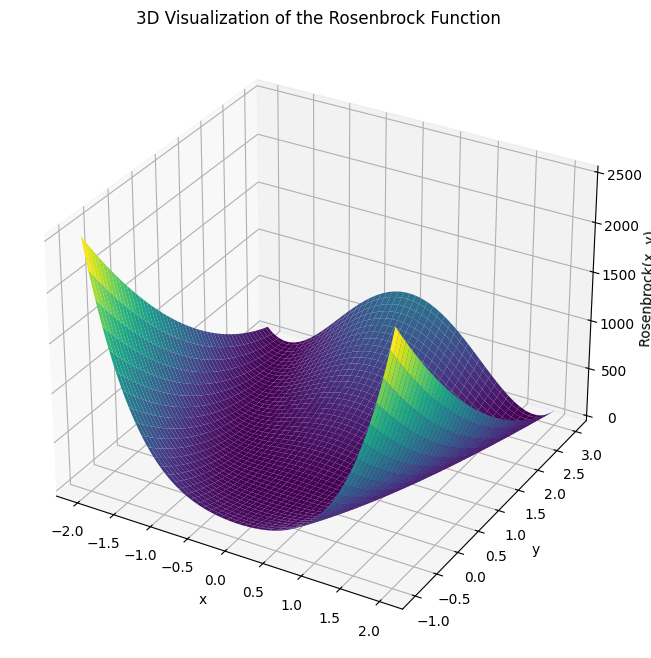

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for x and y values
x_vals = np.linspace(-2, 2, 200)
y_vals = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate Z values using the rosenbrock function
Z = rosenbrock(X, Y)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Add labels and title
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Rosenbrock(x, y)')
ax.set_title('3D Visualization of the Rosenbrock Function')

plt.show()

In [3]:
import numpy as np

def rosenbrock(x, y):
  return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
  dy = 200 * (y - x**2)
  return np.array([dx, dy])

def sgd_with_momentum(start, lr=0.001, beta=0.9, steps=1000):
  """
  SGD with classical momentum.
  v = beta * v + gradient
  theta = theta - lr * v
  """
  x, y = start
  velocity = np.array([0.0, 0.0])
  path = [(x, y)]
  losses = [rosenbrock(x, y)]

  for _ in range(steps):
      grad = rosenbrock_grad(x, y)
      velocity = beta * velocity + grad
      x = x - lr * velocity[0]
      y = y - lr * velocity[1]
      path.append((x, y))
      losses.append(rosenbrock(x, y))

  return np.array(path), np.array(losses)

def count_sign_changes(path):
  """Count direction reversals (oscillations) in the x-dimension."""
  dx = np.diff(path[:, 0])
  return int(np.sum(np.abs(np.diff(np.sign(dx))) > 0))

# Compare three momentum values
start = (-1.5, 1.5)
configs = [
  ("no momentum", 0.0),
  ("standard",    0.9),
  ("high",        0.99),
]

print("Momentum Comparison (target: 1.0, 1.0)")
print("=" * 55)

for label, beta in configs:
  path, losses = sgd_with_momentum(start, lr=0.001, beta=beta, steps=2000)
  dist = np.linalg.norm(path[-1] - np.array([1.0, 1.0]))
  osc = count_sign_changes(path)

  print("\nbeta = {:.2f} ({}):".format(beta, label))
  print("  Final: ({:.4f}, {:.4f})".format(path[-1][0], path[-1][1]))
  print("  Final loss:    {:.6f}".format(losses[-1]))
  print("  Dist to opt:   {:.4f}".format(dist))
  print("  Oscillations:  {}".format(osc))
  print("  Effective lr:  {:.4f}".format(0.001 / (1 - beta) if beta < 1 else float('inf')))

Momentum Comparison (target: 1.0, 1.0)

beta = 0.00 (no momentum):
  Final: (0.6544, 0.4265)
  Final loss:    0.119731
  Dist to opt:   0.6696
  Oscillations:  8
  Effective lr:  0.0010

beta = 0.90 (standard):
  Final: (0.9999, 0.9998)
  Final loss:    0.000000
  Dist to opt:   0.0002
  Oscillations:  16
  Effective lr:  0.0100

beta = 0.99 (high):
  Final: (nan, nan)
  Final loss:    nan
  Dist to opt:   nan
  Oscillations:  21
  Effective lr:  0.1000


/tmp/ipykernel_2496/3224802712.py:4: RuntimeWarning: overflow encountered in scalar power
  return (1 - x)**2 + 100 * (y - x**2)**2
/tmp/ipykernel_2496/3224802712.py:7: RuntimeWarning: overflow encountered in scalar power
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_2496/3224802712.py:8: RuntimeWarning: overflow encountered in scalar power
  dy = 200 * (y - x**2)
/tmp/ipykernel_2496/3224802712.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return (1 - x)**2 + 100 * (y - x**2)**2
/tmp/ipykernel_2496/3224802712.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_2496/3224802712.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 200 * (y - x**2)


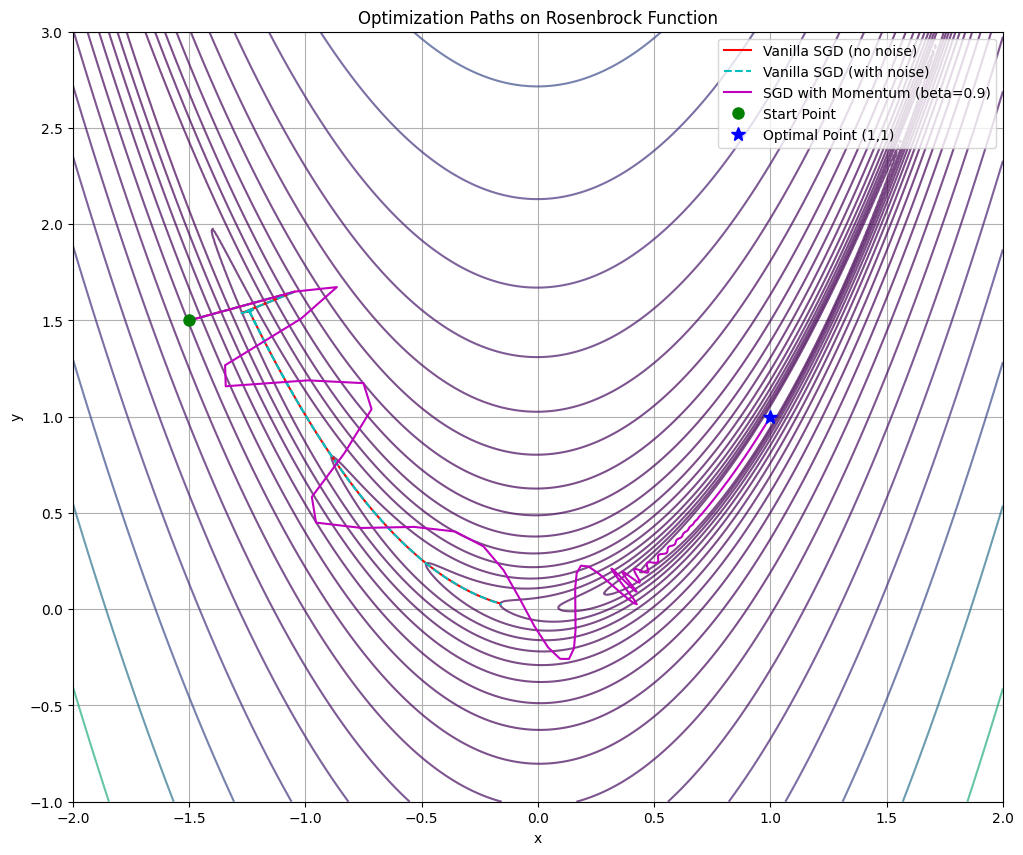

In [4]:
import matplotlib.pyplot as plt

# Re-generate the paths (as the previous cell only printed summaries)
np.random.seed(42) # Ensure reproducibility for vanilla_sgd with noise
start = (-1.5, 1.5)

path_clean, _ = vanilla_sgd(start, lr=0.001, steps=1000, noise_std=0)
path_noisy, _ = vanilla_sgd(start, lr=0.001, steps=1000, noise_std=0.5)
path_momentum_no_osc, _ = sgd_with_momentum(start, lr=0.001, beta=0.0, steps=2000)
path_momentum_standard, _ = sgd_with_momentum(start, lr=0.001, beta=0.9, steps=2000)

# Create a meshgrid for the contour plot
x_vals_plot = np.linspace(-2, 2, 400)
y_vals_plot = np.linspace(-1, 3, 400)
X_plot, Y_plot = np.meshgrid(x_vals_plot, y_vals_plot)
Z_plot = rosenbrock(X_plot, Y_plot)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111)

# Plot the Rosenbrock function contours
ax.contour(X_plot, Y_plot, Z_plot, levels=np.logspace(-0.5, 3.5, 20), cmap='viridis', alpha=0.7)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Optimization Paths on Rosenbrock Function')

# Plot the paths
ax.plot(np.array(path_clean)[:, 0], np.array(path_clean)[:, 1], 'r-', label='Vanilla SGD (no noise)', linewidth=1.5)
ax.plot(np.array(path_noisy)[:, 0], np.array(path_noisy)[:, 1], 'c--', label='Vanilla SGD (with noise)', linewidth=1.5)
ax.plot(np.array(path_momentum_standard)[:, 0], np.array(path_momentum_standard)[:, 1], 'm-', label='SGD with Momentum (beta=0.9)', linewidth=1.5)

# Mark start and optimal points
ax.plot(start[0], start[1], 'go', markersize=8, label='Start Point')
ax.plot(1, 1, 'b*', markersize=10, label='Optimal Point (1,1)')

ax.set_xlim([-2, 2])
ax.set_ylim([-1, 3])
ax.legend()
ax.grid(True)
plt.show()

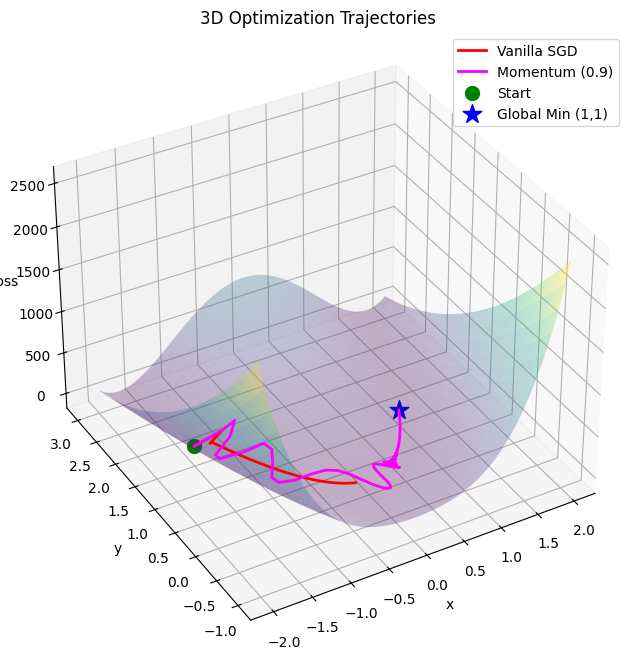

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Reuse the existing meshgrid and Z values
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with lower alpha to see paths through it
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')

# Extract paths for plotting
clean_x, clean_y = np.array(path_clean)[:, 0], np.array(path_clean)[:, 1]
clean_z = rosenbrock(clean_x, clean_y)

mom_x, mom_y = np.array(path_momentum_standard)[:, 0], np.array(path_momentum_standard)[:, 1]
mom_z = rosenbrock(mom_x, mom_y)

# Plot 3D paths
ax.plot(clean_x, clean_y, clean_z, color='red', label='Vanilla SGD', linewidth=2, zorder=10)
ax.plot(mom_x, mom_y, mom_z, color='magenta', label='Momentum (0.9)', linewidth=2, zorder=10)

# Mark Start and End
ax.scatter(start[0], start[1], rosenbrock(start[0], start[1]), color='green', s=100, label='Start')
ax.scatter(1, 1, 0, color='blue', marker='*', s=200, label='Global Min (1,1)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Loss')
ax.set_title('3D Optimization Trajectories')
ax.legend()

# Set a better initial view angle
ax.view_init(elev=35, azim=-120)

plt.show()

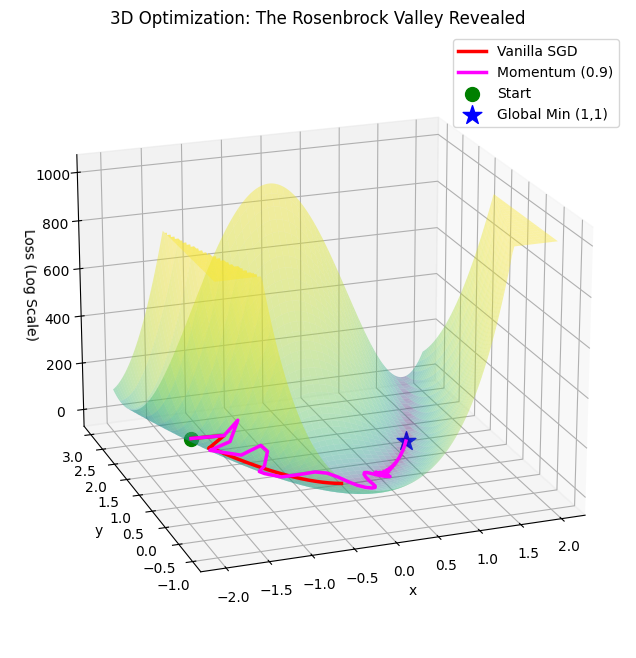

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Create a new 3D plot with Log Scaling for the Z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# We use LogNorm to make the valley floor visible
# We also clip Z to a reasonable range so the 'walls' don't squash the floor
Z_clipped = np.clip(Z, 1e-1, 1000)

surf = ax.plot_surface(X, Y, Z_clipped, cmap='viridis', alpha=0.4,
                       norm=LogNorm(), edgecolor='none')

# Overlay the paths again
ax.plot(clean_x, clean_y, np.clip(clean_z, 0.1, 1000), color='red', label='Vanilla SGD', linewidth=2.5, zorder=20)
ax.plot(mom_x, mom_y, np.clip(mom_z, 0.1, 1000), color='magenta', label='Momentum (0.9)', linewidth=2.5, zorder=20)

# Mark Start and End
ax.scatter(start[0], start[1], rosenbrock(start[0], start[1]), color='green', s=100, label='Start')
ax.scatter(1, 1, 0.1, color='blue', marker='*', s=200, label='Global Min (1,1)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Loss (Log Scale)')
ax.set_title('3D Optimization: The Rosenbrock Valley Revealed')
ax.legend()

# A shallow angle helps see 'into' the valley
ax.view_init(elev=20, azim=-110)

plt.show()

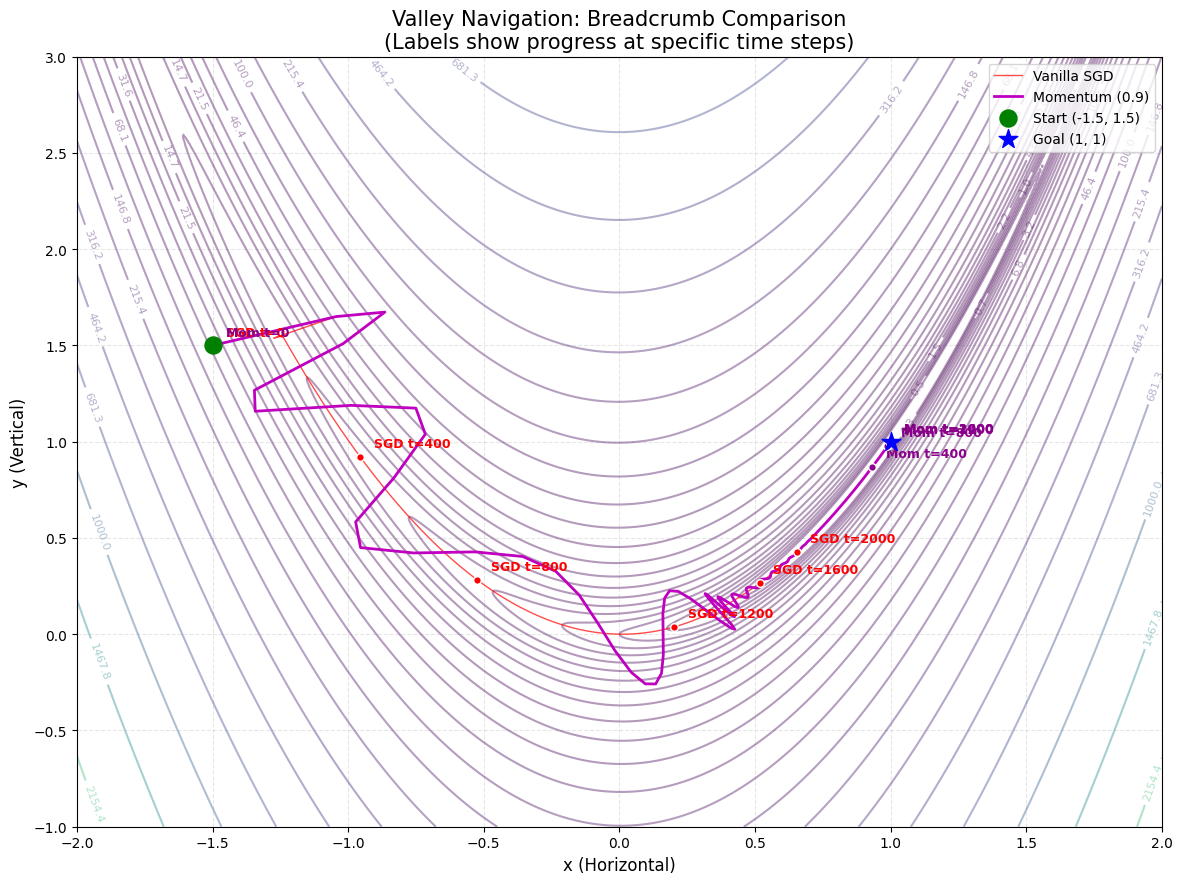

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Re-run simulations for long enough to see the full trajectory
start_pt = np.array([-1.5, 1.5])
steps = 2000
label_interval = 400

path_vanilla, _ = vanilla_sgd(start_pt, lr=0.001, steps=steps, noise_std=0)
path_mom, _ = sgd_with_momentum(start_pt, lr=0.001, beta=0.9, steps=steps)

# Setup Plot
plt.figure(figsize=(14, 10))
x_vals = np.linspace(-2, 2, 500)
y_vals = np.linspace(-1, 3, 500)
X, Y = np.meshgrid(x_vals, y_vals)
Z = rosenbrock(X, Y)

# Use Log-spaced contours to highlight the valley floor
contours = plt.contour(X, Y, Z, levels=np.logspace(-0.5, 3.5, 25), cmap='viridis', alpha=0.4)
plt.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Plot Trajectories
plt.plot(path_vanilla[:, 0], path_vanilla[:, 1], 'r-', label='Vanilla SGD', linewidth=1, alpha=0.7)
plt.plot(path_mom[:, 0], path_mom[:, 1], 'm-', label='Momentum (0.9)', linewidth=2)

# Helper to add breadcrumbs/labels
def add_breadcrumbs(path, color, name):
    for i in range(0, len(path), label_interval):
        plt.scatter(path[i, 0], path[i, 1], color=color, s=30, edgecolors='white', zorder=5)
        plt.text(path[i, 0] + 0.05, path[i, 1] + 0.05, f'{name} t={i}', fontsize=9, color=color, fontweight='bold')

add_breadcrumbs(path_vanilla, 'red', 'SGD')
add_breadcrumbs(path_mom, 'darkmagenta', 'Mom')

# Mark Key Points
plt.scatter(*start_pt, color='green', s=150, marker='o', label='Start (-1.5, 1.5)', zorder=6)
plt.scatter(1, 1, color='blue', s=200, marker='*', label='Goal (1, 1)', zorder=6)

plt.title('Valley Navigation: Breadcrumb Comparison\n(Labels show progress at specific time steps)', fontsize=15)
plt.xlabel('x (Horizontal)', fontsize=12)
plt.ylabel('y (Vertical)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

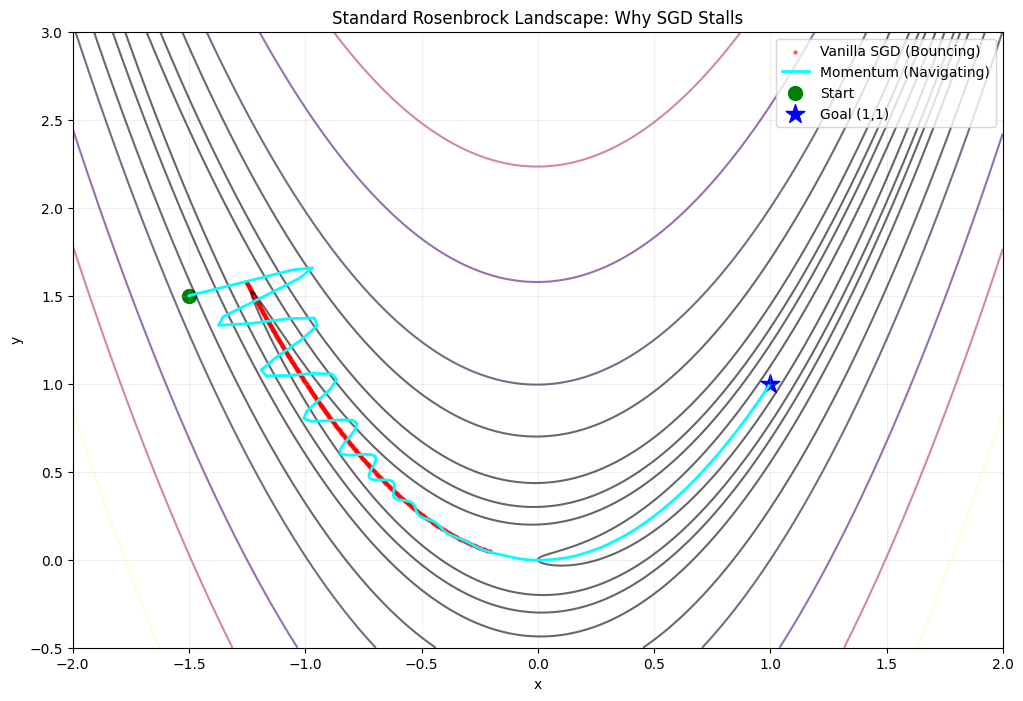

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Standard Rosenbrock and Gradients
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# Run paths
start = np.array([-1.5, 1.5])
path_sgd, _ = vanilla_sgd(start, lr=0.0005, steps=2000) # Lower LR to show the 'vibration'
path_mom, _ = sgd_with_momentum(start, lr=0.0005, beta=0.9, steps=2000)

# Create Grid
x = np.linspace(-2, 2, 400)
y = np.linspace(-0.5, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

plt.figure(figsize=(12, 8))
# Use standard linear levels to show the steepness
plt.contour(X, Y, Z, levels=[1, 5, 10, 20, 50, 100, 250, 500, 1000], cmap='magma', alpha=0.6)

# Plot the paths as dots to show the 'speed' (density of points)
plt.scatter(path_sgd[::5, 0], path_sgd[::5, 1], color='red', s=5, label='Vanilla SGD (Bouncing)', alpha=0.5)
plt.plot(path_mom[:, 0], path_mom[:, 1], color='cyan', linewidth=2, label='Momentum (Navigating)')

plt.scatter(*start, color='green', s=100, label='Start')
plt.scatter(1, 1, color='blue', marker='*', s=200, label='Goal (1,1)')

plt.title('Standard Rosenbrock Landscape: Why SGD Stalls')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

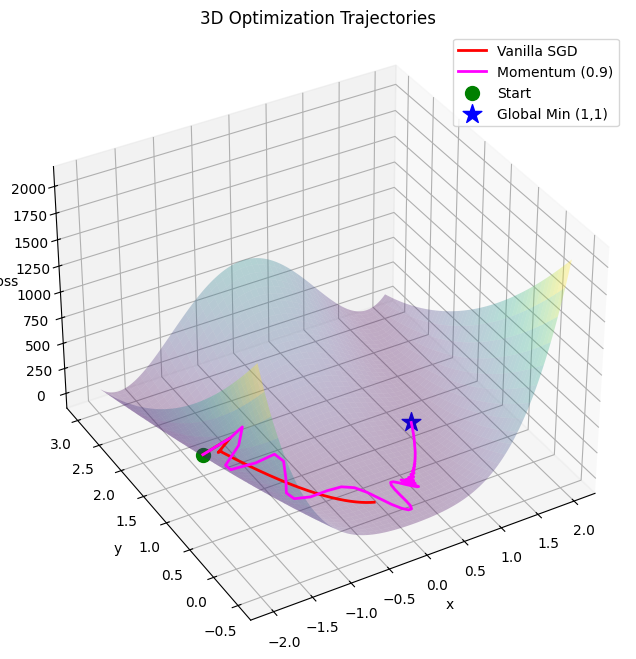

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Reuse the existing meshgrid and Z values
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with lower alpha to see paths through it
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')

# Extract paths for plotting
clean_x, clean_y = np.array(path_clean)[:, 0], np.array(path_clean)[:, 1]
clean_z = rosenbrock(clean_x, clean_y)

mom_x, mom_y = np.array(path_momentum_standard)[:, 0], np.array(path_momentum_standard)[:, 1]
mom_z = rosenbrock(mom_x, mom_y)

# Plot 3D paths
ax.plot(clean_x, clean_y, clean_z, color='red', label='Vanilla SGD', linewidth=2, zorder=10)
ax.plot(mom_x, mom_y, mom_z, color='magenta', label='Momentum (0.9)', linewidth=2, zorder=10)

# Mark Start and End
ax.scatter(start[0], start[1], rosenbrock(start[0], start[1]), color='green', s=100, label='Start')
ax.scatter(1, 1, 0, color='blue', marker='*', s=200, label='Global Min (1,1)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Loss')
ax.set_title('3D Optimization Trajectories')
ax.legend()

# Set a better initial view angle
ax.view_init(elev=35, azim=-120)

plt.show()

In [9]:
import numpy as np

def rosenbrock(x, y):
  return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
  dy = 200 * (y - x**2)
  return np.array([dx, dy])

def sgd_classical_momentum(start, lr, beta, steps):
  """Classical momentum: gradient at current position."""
  x, y = start
  v = np.array([0.0, 0.0])
  losses = [rosenbrock(x, y)]

  for _ in range(steps):
      grad = rosenbrock_grad(x, y)
      v = beta * v + grad
      x = x - lr * v[0]
      y = y - lr * v[1]
      losses.append(rosenbrock(x, y))

  return np.array([x, y]), np.array(losses)

def sgd_nesterov_momentum(start, lr, beta, steps):
  """Nesterov momentum: gradient at look-ahead position."""
  x, y = start
  v = np.array([0.0, 0.0])
  losses = [rosenbrock(x, y)]

  for _ in range(steps):
      # Look ahead: where would momentum take us?
      look_x = x - lr * beta * v[0]
      look_y = y - lr * beta * v[1]

      # Compute gradient at the look-ahead position
      grad = rosenbrock_grad(look_x, look_y)
      v = beta * v + grad

      x = x - lr * v[0]
      y = y - lr * v[1]
      losses.append(rosenbrock(x, y))

  return np.array([x, y]), np.array(losses)

# Compare all three variants
start = (-1.5, 1.5)
lr = 0.001
steps = 3000

results = {}
for name, fn in [("Vanilla SGD", lambda: sgd_classical_momentum(start, lr, 0.0, steps)),
               ("Classical Momentum", lambda: sgd_classical_momentum(start, lr, 0.9, steps)),
               ("Nesterov Momentum", lambda: sgd_nesterov_momentum(start, lr, 0.9, steps))]:
  final_pos, losses = fn()
  results[name] = (final_pos, losses)

print("SGD Variant Comparison (3000 steps, lr={})".format(lr))
print("=" * 55)

for name, (final_pos, losses) in results.items():
  dist = np.linalg.norm(final_pos - np.array([1.0, 1.0]))

  # Find step where loss first drops below 1.0 (if ever)
  below_1 = np.where(losses < 1.0)[0]
  first_below = below_1[0] if len(below_1) > 0 else -1

  print("\n{}:".format(name))
  print("  Final loss:       {:.6f}".format(losses[-1]))
  print("  Dist to optimum:  {:.4f}".format(dist))
  print("  Steps to loss<1:  {}".format(first_below if first_below > 0 else "never"))

print("\n" + "=" * 55)
print("Nesterov often converges faster near the minimum")
print("because it 'brakes' before overshooting.")

SGD Variant Comparison (3000 steps, lr=0.001)

Vanilla SGD:
  Final loss:       0.034565
  Dist to optimum:  0.3855
  Steps to loss<1:  1081

Classical Momentum:
  Final loss:       0.000000
  Dist to optimum:  0.0000
  Steps to loss<1:  24

Nesterov Momentum:
  Final loss:       0.000000
  Dist to optimum:  0.0000
  Steps to loss<1:  29

Nesterov often converges faster near the minimum
because it 'brakes' before overshooting.


In [11]:
import numpy as np

def rosenbrock(x, y):
  return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
  dy = 200 * (y - x**2)
  return np.array([dx, dy])

def sgd_with_momentum(start, lr, beta, steps):
  x, y = start
  velocity = np.array([0.0, 0.0])
  losses = []

  for _ in range(steps):
      losses.append(rosenbrock(x, y))
      grad = rosenbrock_grad(x, y)
      velocity = beta * velocity + grad
      x = x - lr * velocity[0]
      y = y - lr * velocity[1]

  losses.append(rosenbrock(x, y))
  return losses

# Three strategies for dealing with high-momentum overshoot
start = (-1.5, 1.5)
configs = [
  ("Broken:  lr=0.001, beta=0.99",   0.001,   0.99),
  ("Fix #1:  Lower lr to 0.0001",     0.0001,  0.99),
  ("Fix #2:  Lower beta to 0.9",      0.001,   0.9),
  ("Fix #3:  Lower both",             0.0005,  0.95),
]

print("Diagnosing Momentum Overshoot")
print("=" * 55)

for name, lr, beta in configs:
  losses = sgd_with_momentum(start, lr, beta, steps=2000)
  final_loss = losses[-1]
  eff_lr = lr / (1 - beta)

  # Check for oscillation: count loss increases
  increases = sum(1 for i in range(1, len(losses)) if losses[i] > losses[i-1])
  pct_increases = 100.0 * increases / len(losses)

  print("\n{}".format(name))
  print("  Effective lr:  {:.4f}".format(eff_lr))
  print("  Final loss:    {:.6f}".format(final_loss))
  print("  Converged:     {}".format("yes" if final_loss < 0.01 else "no"))
  print("  Loss went up:  {:.1f}% of steps".format(pct_increases))

print("\n" + "=" * 55)
print("Lesson: lowering beta is usually cheaper than lowering lr,")
print("because it preserves the base step size while reducing inertia.")

Diagnosing Momentum Overshoot

Broken:  lr=0.001, beta=0.99
  Effective lr:  0.1000
  Final loss:    nan
  Converged:     no
  Loss went up:  1.3% of steps

Fix #1:  Lower lr to 0.0001
  Effective lr:  0.0100
  Final loss:    0.000000
  Converged:     yes
  Loss went up:  49.2% of steps

Fix #2:  Lower beta to 0.9
  Effective lr:  0.0100
  Final loss:    0.000000
  Converged:     yes
  Loss went up:  2.0% of steps

Fix #3:  Lower both
  Effective lr:  0.0100
  Final loss:    0.000000
  Converged:     yes
  Loss went up:  4.7% of steps

Lesson: lowering beta is usually cheaper than lowering lr,
because it preserves the base step size while reducing inertia.


/tmp/ipykernel_2496/129605225.py:4: RuntimeWarning: overflow encountered in scalar power
  return (1 - x)**2 + 100 * (y - x**2)**2
/tmp/ipykernel_2496/129605225.py:7: RuntimeWarning: overflow encountered in scalar power
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_2496/129605225.py:8: RuntimeWarning: overflow encountered in scalar power
  dy = 200 * (y - x**2)
/tmp/ipykernel_2496/129605225.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return (1 - x)**2 + 100 * (y - x**2)**2
/tmp/ipykernel_2496/129605225.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/tmp/ipykernel_2496/129605225.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 200 * (y - x**2)


Step 4: The "loss went up" metric is diagnostic. If more than ~20% of steps increase loss, your optimizer is unstable. This metric is cheap to log and catches momentum problems early in a training run.

if you’re overshooting because beta is too high, it’s usually better to lower beta than to dramatically shrink lr, because you keep a healthy base step size (so training remains fast) while simply reducing the “inertia” that was causing huge effective steps.

The warnings at the end (overflow encountered, nan) are just NumPy telling you the Broken config made the Rosenbrock value blow up to infinity due to those overly large steps.

Does it help if I rephrase this as: “overshoot happens because lr and beta together act like a single big lr, and lowering beta is a cheaper way to reduce that big lr than shrinking lr itself”?

but why does base step size matter, doesnt the effective lr matter which is same for speed of convergence?

Effective lr tells you the steady-state step size, but base lr and β still matter for how you get there: stability, responsiveness, and how much you overshoot.

Why base lr still matters
Momentum dynamics:
v
t
+
1
=
β
v
t
+
(
1
−
β
)
∇
L
t
,
w
t
+
1
=
w
t
−
lr

v
t
+
1
v
t+1
​
 =βv
t
​
 +(1−β)∇L
t
​
 ,w
t+1
​
 =w
t
​
 −lrv
t+1
​
 .

The “effective lr ≈ lr/(1−β)” is an asymptotic approximation assuming gradients don’t change much and velocity has settled.

Transients: with high β, velocity builds up slowly and lags behind the current gradient; two settings with the same lr/(1−β) can have very different early‑step behavior, overshoot, and oscillations.

Noise responsiveness: higher base lr and lower β means updates respond more quickly to gradient changes (less old-gradient inertia) while still having a similar long‑run step size; that’s why lowering β (rather than lr) made the “loss went up” percentage small while keeping training fast in the lesson.

So “same effective lr” is a coarse guide for asymptotic step size, but (lr, β) is a 2D knob, not a 1D one: β controls inertia / smoothing and how aggressively old gradients keep pushing, while lr scales each new gradient’s influence directly. Two pairs with the same lr/(1−β) can have meaningfully different convergence speed, overshoot, and stability.

Would it help if I walk through one concrete comparison, like (lr=1e−3, β=0.9) vs (lr=1e−4, β=0.99) on the same 1D quadratic, step by step?




Step 4: The "loss went up" metric is diagnostic.

Scale	What Changes	Typical Response
Small model (10M params)	Vanilla SGD often sufficient; noise provides enough regularization	lr=0.01, β=0.9, batch=32
Large batch (4K-32K)	Less noise per step; optimizer converges faster but to sharper minima	Scale lr linearly with batch; keep β=0.9; add warmup
Deep model (100+ layers)	Gradient magnitude varies 100x across layers; single lr struggles	Switch to Adam (per-parameter lr) or use per-layer lr scaling
Very long training (100K+ steps)	Momentum velocity accumulates stale gradients across LR schedule changes	Restart momentum at schedule boundaries; or use warmup after decay steps

Adam “wins” in those cases because it gives per-parameter adaptive learning rates, which helps when gradients are badly scaled, noisy, or very different across parameters or layers.

Language models
LMs have heavy-tailed, sparse, and highly anisotropic gradients (e.g., rare tokens, layer norms, attention vs MLP).

Adam keeps per-parameter estimates of mean and variance of gradients, so parameters with consistently small or rare gradients get relatively larger effective steps, while very noisy ones get smaller steps.

This adaptivity makes optimization more stable and faster on the weird, ill‑conditioned loss surfaces typical for LMs, where plain SGD would need very careful lr schedules and still underperform.

Fine-tuning
In fine-tuning, some layers should barely move (e.g., lower layers), others should move a lot (e.g., new head, adapter).

Adam’s per-parameter lr automatically downscales “easy” or saturated directions and upscales small but important ones, so you often get good results without hand‑designed layerwise lr multipliers.

Multi-modal models
Different modalities (text, images, audio) produce gradients with very different scales and statistics through different parts of the network.

A single global lr (as in vanilla SGD) is a bad fit; Adam lets each parameter “self-tune” based on its own gradient history, smoothing out these scale mismatches.

So the claim “Adam wins here” is: in regimes with ill‑conditioned, heterogeneous, or sparse gradients, that per-parameter adaptivity is worth the extra memory and often gives better optimization than SGD+momentum.

In your own work, are you more often in the “big vision backbone from scratch” regime or the “transformer LM / multimodal / finetuning” regime when choosing between SGD and Adam?




So the heuristic is: “scale lr linearly with batch, but only after a warmup phase,” and that’s why the line says “linear-scaling warmup.

 A team switches from batch size 256 to batch size 2048 (8x increase). Using the sqrt-scaling noise rule, what should the new learning rate be if the original was lr=0.1? How does that compare to the linear-scaling warmup heuristic?

The loss surface is unchanged; what changed is the optimizer dynamics when lr stepped down while the velocity still reflected pre‑decay gradients.

That mismatch can cause a few bad steps right after the lr drop (velocity pointing somewhere no longer appropriate), giving a spike, after which momentum re-aligns and the loss slowly recovers.

SGD+momentum: same lr for all params, momentum smooths noise and helps follow consistent gradient directions; often better generalization in vision when tuned.

Adam: adapts step size per parameter based on gradient history, usually converges faster and is more robust to bad lr choices, especially with heterogeneous/sparse gradients (e.g., LMs).

SGD+momentum must pick one lr that’s small enough for the sharpest direction, which makes progress slow in flatter ones; Adam auto‑normalizes gradients so it can move quickly in flat or under-updated directions without exploding in sharp ones.

Adam gives each parameter its own effective learning rate by dividing by the running RMS of its gradients. Parameters with noisy gradients get smaller updates; parameters with consistent gradients get larger updates. This is adaptive normalization, not just momentum.

𝑣
𝑡
=
𝛽
2
𝑣
𝑡
−
1
+
(
1
−
𝛽
2
)
𝑔
𝑡
2
v
t
	​

=β
2
	​

v
t−1
	​

+(1−β
2
	​

)g
t
2
	​


𝑔
𝑡
g
t
	​

: gradient
𝑔
𝑡
2
g
t
2
	​

: elementwise square of gradient
𝑣
𝑡
v
t
	​

: running average of those squares
Intuition
𝑚
𝑡
m
t
	​

 → direction (like momentum)
𝑣
𝑡
v
t
	​

 → magnitude tracker

👉 Think of
𝑣
𝑡
v
t
	​

 as:

“How big (or noisy) have the gradients been recently?”

Why square the gradient?

Because:

Squaring makes everything positive
Bigger gradients → much bigger contribution
Captures variance / scale
What does Adam do with
𝑣
𝑡
v
t
	​

?

In the update:

𝑚
𝑡
𝑣
𝑡
v
t
	​

	​

m
t
	​

	​


👉 If gradients are large or unstable →
𝑣
𝑡
v
t
	​

 is big → step gets smaller
👉 If gradients are small →
𝑣
𝑡
v
t
	​

 is small → step stays larger

Why both
𝑚
m and
𝑣
v?
𝑚
m: smooth direction (like momentum)
𝑣
v: normalize step size (like RMSProp)

Together = fast + stable + adaptive

One-line answer

You need
𝑚
m because:

raw gradients are noisy and inconsistent, and momentum turns them into a stable direction to follow.

𝑔
=
∇
𝐿
+
𝜆
𝜃
g=∇L+λθ → “old-school Adam style, decay baked into gradient”
AdamW → “gradient for the loss only, decay applied directly to weight”

AdamW fixes this: apply weight decay after the adaptive scaling: θ = θ - lr × (m̂/√v̂ + λθ)

In [1]:
import numpy as np

class AdamW:
  """
  AdamW optimizer implementation.

  The key insight: weight decay is applied AFTER the adaptive
  scaling, not as part of the gradient. This matters because
  adaptive methods scale gradients—if weight decay is part of
  the gradient, it gets scaled too (wrong!).
  """
  def __init__(self, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
      self.lr = lr
      self.beta1, self.beta2 = betas
      self.eps = eps
      self.weight_decay = weight_decay
      self.m = {}  # First moments
      self.v = {}  # Second moments
      self.t = 0   # Timestep

  def step(self, params, grads):
      """
      Perform one optimization step.

      params: dict of parameter arrays
      grads: dict of gradient arrays (same keys as params)
      """
      self.t += 1

      for name in params:
          p = params[name]
          g = grads[name]

          # Initialize moments on first step
          if name not in self.m:
              self.m[name] = np.zeros_like(p)
              self.v[name] = np.zeros_like(p)

          # Update biased first moment estimate
          self.m[name] = self.beta1 * self.m[name] + (1 - self.beta1) * g

          # Update biased second moment estimate
          self.v[name] = self.beta2 * self.v[name] + (1 - self.beta2) * g**2

          # Compute bias-corrected estimates
          m_hat = self.m[name] / (1 - self.beta1**self.t)
          v_hat = self.v[name] / (1 - self.beta2**self.t)

          # AdamW update: weight decay is SEPARATE from gradient
          adam_update = m_hat / (np.sqrt(v_hat) + self.eps)
          params[name] -= self.lr * (adam_update + self.weight_decay * p)

      return params

# Demo: Compare Adam vs AdamW on a simple problem
np.random.seed(42)

# Initialize parameters
params_adam = {"w": np.array([2.0, -1.0, 0.5])}
params_adamw = {"w": np.array([2.0, -1.0, 0.5])}

optimizer_adam = AdamW(lr=0.1, weight_decay=0.0)   # No weight decay
optimizer_adamw = AdamW(lr=0.1, weight_decay=0.1)  # With weight decay

print("AdamW Demo: Decoupled Weight Decay")
print("=" * 50)
print(f"Initial weights: {params_adam['w']}")
print()

# Simulate a few steps with random gradients
for step in range(5):
  grad = np.random.randn(3) * 0.1  # Small random gradient

  params_adam = optimizer_adam.step(params_adam, {"w": grad})
  params_adamw = optimizer_adamw.step(params_adamw, {"w": grad})

print(f"After 5 steps:")
print(f"  Without weight decay: {params_adam['w']}")
print(f"  With weight decay:    {params_adamw['w']}")
print()
print("Notice: Weight decay pulls parameters toward zero!")
print(f"  L2 norm without decay: {np.linalg.norm(params_adam['w']):.3f}")
print(f"  L2 norm with decay:    {np.linalg.norm(params_adamw['w']):.3f}")

AdamW Demo: Decoupled Weight Decay
Initial weights: [ 2.  -1.   0.5]

After 5 steps:
  Without weight decay: [ 1.5429162  -0.78237453  0.47395848]
  With weight decay:    [ 1.45434439 -0.73956471  0.45390726]

Notice: Weight decay pulls parameters toward zero!
  L2 norm without decay: 1.794
  L2 norm with decay:    1.694


In [2]:
import numpy as np

def cosine_lr_schedule(step, total_steps, warmup_steps, max_lr, min_lr=0):
  """
  Learning rate schedule with linear warmup and cosine decay.

  This is the de facto standard for modern LLM training:
  1. Linear warmup from 0 to max_lr
  2. Cosine decay from max_lr to min_lr
  """
  if step < warmup_steps:
      # Linear warmup: 0 → max_lr
      return max_lr * step / warmup_steps
  else:
      # Cosine decay: max_lr → min_lr
      progress = (step - warmup_steps) / (total_steps - warmup_steps)
      return min_lr + 0.5 * (max_lr - min_lr) * (1 + np.cos(np.pi * progress))

# Visualize the schedule
total_steps = 10000
warmup_steps = 1000
max_lr = 1e-4
min_lr = 1e-6

# Calculate LR at key points
checkpoints = [0, warmup_steps//2, warmup_steps, total_steps//2, total_steps-1]

print("Cosine LR Schedule with Warmup")
print("=" * 50)
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Max LR: {max_lr}")
print(f"Min LR: {min_lr}")
print()

print("Learning rate at key points:")
for step in checkpoints:
  lr = cosine_lr_schedule(step, total_steps, warmup_steps, max_lr, min_lr)
  phase = "warmup" if step < warmup_steps else "decay"
  print(f"  Step {step:5d} ({phase:6s}): {lr:.2e}")

# Show the full curve
print()
print("Schedule shape:")
lrs = [cosine_lr_schedule(s, total_steps, warmup_steps, max_lr, min_lr)
     for s in range(0, total_steps, total_steps//20)]
max_bar = 40
for i, lr in enumerate(lrs):
  bar_len = int((lr / max_lr) * max_bar)
  step = i * (total_steps // 20)
  print(f"  {step:5d} {'█' * bar_len}")

Cosine LR Schedule with Warmup
Total steps: 10000
Warmup steps: 1000
Max LR: 0.0001
Min LR: 1e-06

Learning rate at key points:
  Step     0 (warmup): 0.00e+00
  Step   500 (warmup): 5.00e-05
  Step  1000 (decay ): 1.00e-04
  Step  5000 (decay ): 5.91e-05
  Step  9999 (decay ): 1.00e-06

Schedule shape:
      0 
    500 ████████████████████
   1000 ████████████████████████████████████████
   1500 ███████████████████████████████████████
   2000 ██████████████████████████████████████
   2500 █████████████████████████████████████
   3000 ███████████████████████████████████
   3500 ████████████████████████████████
   4000 ██████████████████████████████
   4500 ██████████████████████████
   5000 ███████████████████████
   5500 ████████████████████
   6000 ████████████████
   6500 █████████████
   7000 ██████████
   7500 ███████
   8000 █████
   8500 ███
   9000 █
   9500 


Warmup (start small → big lr): Early on, weights are random and curvature is high, so a huge lr can cause divergence or wild loss spikes; warmup lets you ramp up into a large lr safely.

Decay (big lr → small lr): Later, once you’re near good minima, you want small, careful steps to refine rather than jump around; decay reduces lr so you can converge and improve final accuracy.

Together: warmup protects the start of training; decay improves the end.

inear Scaling Rule

When you increase batch size, gradient noise decreases. You can take bigger steps:

lr_new = lr_base × (batch_new / batch_base)

This works up to a point (~32K batch size for ImageNet), then breaks down.

his works well up to some critical batch size (for ImageNet, around 32k), beyond which simply scaling lr linearly stops helping and can hurt convergence/generalization.



In [3]:
import numpy as np

def estimate_gradient_noise(batch_size, data_variance=1.0):
  """
  Estimate gradient noise as a function of batch size.

  Central limit theorem: variance of mean scales as 1/n
  """
  return data_variance / np.sqrt(batch_size)

def linear_lr_scaling(base_lr, base_batch, new_batch):
  """Linear scaling rule for learning rate."""
  return base_lr * (new_batch / base_batch)

# Compare different batch sizes
base_lr = 0.001
base_batch = 256

print("Batch Size ↔ Learning Rate Scaling")
print("=" * 50)
print(f"Base config: batch={base_batch}, lr={base_lr}")
print()

batch_sizes = [256, 512, 1024, 2048, 4096, 8192, 32768]

print("Batch Size  |  Gradient Noise  |  Scaled LR")
print("-" * 50)

for batch in batch_sizes:
  noise = estimate_gradient_noise(batch)
  scaled_lr = linear_lr_scaling(base_lr, base_batch, batch)

  print(f"  {batch:6d}   |     {noise:.4f}       |   {scaled_lr:.4f}")

print()
print("⚠️  Beyond ~32K batch, linear scaling often breaks!")
print("    - Gradient noise reduction saturates")
print("    - Need sophisticated techniques (LARS, LAMB)")

Batch Size ↔ Learning Rate Scaling
Base config: batch=256, lr=0.001

Batch Size  |  Gradient Noise  |  Scaled LR
--------------------------------------------------
     256   |     0.0625       |   0.0010
     512   |     0.0442       |   0.0020
    1024   |     0.0312       |   0.0040
    2048   |     0.0221       |   0.0080
    4096   |     0.0156       |   0.0160
    8192   |     0.0110       |   0.0320
   32768   |     0.0055       |   0.1280

⚠️  Beyond ~32K batch, linear scaling often breaks!
    - Gradient noise reduction saturates
    - Need sophisticated techniques (LARS, LAMB)


In [4]:
import numpy as np

def cosine_lr_schedule(step, total_steps, warmup_steps, max_lr, min_lr=0):
  """
  Learning rate schedule with linear warmup and cosine decay.

  This is the de facto standard for modern LLM training:
  1. Linear warmup from 0 to max_lr
  2. Cosine decay from max_lr to min_lr
  """
  if step < warmup_steps:
      # Linear warmup: 0 → max_lr
      return max_lr * step / warmup_steps
  else:
      # Cosine decay: max_lr → min_lr
      progress = (step - warmup_steps) / (total_steps - warmup_steps)
      return min_lr + 0.5 * (max_lr - min_lr) * (1 + np.cos(np.pi * progress))

# Visualize the schedule
total_steps = 10000
warmup_steps = 1000
max_lr = 1e-4
min_lr = 1e-6

# Calculate LR at key points
checkpoints = [0, warmup_steps//2, warmup_steps, total_steps//2, total_steps-1]

print("Cosine LR Schedule with Warmup")
print("=" * 50)
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Max LR: {max_lr}")
print(f"Min LR: {min_lr}")
print()

print("Learning rate at key points:")
for step in checkpoints:
  lr = cosine_lr_schedule(step, total_steps, warmup_steps, max_lr, min_lr)
  phase = "warmup" if step < warmup_steps else "decay"
  print(f"  Step {step:5d} ({phase:6s}): {lr:.2e}")

# Show the full curve
print()
print("Schedule shape:")
lrs = [cosine_lr_schedule(s, total_steps, warmup_steps, max_lr, min_lr)
     for s in range(0, total_steps, total_steps//20)]
max_bar = 40
for i, lr in enumerate(lrs):
  bar_len = int((lr / max_lr) * max_bar)
  step = i * (total_steps // 20)
  print(f"  {step:5d} {'█' * bar_len}")

Cosine LR Schedule with Warmup
Total steps: 10000
Warmup steps: 1000
Max LR: 0.0001
Min LR: 1e-06

Learning rate at key points:
  Step     0 (warmup): 0.00e+00
  Step   500 (warmup): 5.00e-05
  Step  1000 (decay ): 1.00e-04
  Step  5000 (decay ): 5.91e-05
  Step  9999 (decay ): 1.00e-06

Schedule shape:
      0 
    500 ████████████████████
   1000 ████████████████████████████████████████
   1500 ███████████████████████████████████████
   2000 ██████████████████████████████████████
   2500 █████████████████████████████████████
   3000 ███████████████████████████████████
   3500 ████████████████████████████████
   4000 ██████████████████████████████
   4500 ██████████████████████████
   5000 ███████████████████████
   5500 ████████████████████
   6000 ████████████████
   6500 █████████████
   7000 ██████████
   7500 ███████
   8000 █████
   8500 ███
   9000 █
   9500 


In [5]:
import numpy as np

def estimate_gradient_noise(batch_size, data_variance=1.0):
  """
  Estimate gradient noise as a function of batch size.

  Central limit theorem: variance of mean scales as 1/n
  """
  return data_variance / np.sqrt(batch_size)

def linear_lr_scaling(base_lr, base_batch, new_batch):
  """Linear scaling rule for learning rate."""
  return base_lr * (new_batch / base_batch)

# Compare different batch sizes
base_lr = 0.001
base_batch = 256

print("Batch Size ↔ Learning Rate Scaling")
print("=" * 50)
print(f"Base config: batch={base_batch}, lr={base_lr}")
print()

batch_sizes = [256, 512, 1024, 2048, 4096, 8192, 32768]

print("Batch Size  |  Gradient Noise  |  Scaled LR")
print("-" * 50)

for batch in batch_sizes:
  noise = estimate_gradient_noise(batch)
  scaled_lr = linear_lr_scaling(base_lr, base_batch, batch)

  print(f"  {batch:6d}   |     {noise:.4f}       |   {scaled_lr:.4f}")

print()
print("⚠️  Beyond ~32K batch, linear scaling often breaks!")
print("    - Gradient noise reduction saturates")
print("    - Need sophisticated techniques (LARS, LAMB)")

Batch Size ↔ Learning Rate Scaling
Base config: batch=256, lr=0.001

Batch Size  |  Gradient Noise  |  Scaled LR
--------------------------------------------------
     256   |     0.0625       |   0.0010
     512   |     0.0442       |   0.0020
    1024   |     0.0312       |   0.0040
    2048   |     0.0221       |   0.0080
    4096   |     0.0156       |   0.0160
    8192   |     0.0110       |   0.0320
   32768   |     0.0055       |   0.1280

⚠️  Beyond ~32K batch, linear scaling often breaks!
    - Gradient noise reduction saturates
    - Need sophisticated techniques (LARS, LAMB)


Fix: scale warmup with batch/lr
You keep batch 2048 and lr 2.4e‑3, but also scale warmup:

New warmup steps ≈ 2,000 × 8 = 16,000

Now:

You reach the big lr much later in “step space,” after a similar amount of data and optimizer time as in the original run.